---
**Title:** 前沿与分布式系统（Frontiers & Distributed Systems）

**Chapter:** 强化学习与大语言模型

**Difficulty:** 中高级

**Estimated Time:** 40 分钟

---

## 1 — 概述

在前面四个 notebook 中，我们构建了基于强化学习的 LLM 对齐的核心算法工具箱：

| Notebook | 算法 | 核心思想 |
|---|---|---|
| 00 | REINFORCE | 策略梯度（Policy Gradient）——最简单的强化学习算法 |
| 01 | PPO | 裁剪目标 + KL 惩罚实现稳定更新 |
| 02 | DPO | 跳过奖励模型——直接优化偏好 |
| 03 | GRPO | 跳过评论家（Critic）——群组相对优势（Group-Relative Advantage） |

这个最终的 notebook **拉远视角**。我们涵盖两大主题：

1. **算法演进与前沿方法**——我们是如何走到这一步的，下一步是什么？
2. **强化学习训练的分布式系统**——使大规模强化学习对齐变得困难的工程挑战。

学完后，你将拥有这个领域的完整心智地图：算法、权衡、系统设计和开放问题。

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from mp_tutorial.fonts import configure_cjk_fonts
configure_cjk_fonts()

from mp_tutorial.viz import draw_method_timeline, draw_rl_algorithm_comparison, draw_rl_gpu_placement
from mp_tutorial.formatting import info_box, comparison_table, formula_breakdown, code_reference

import warnings
warnings.filterwarnings("ignore", message="Glyph.*missing from font", category=UserWarning)

torch.manual_seed(42)
print("Ready!")

Ready!


## 2 — 完整算法对比

我们已经见过四种用于 LLM 对齐的强化学习算法。在深入前沿之前，让我们把它们并排放在一起，在一个地方比较它们的权衡。

In [2]:
comparison_table(
    headers=["Algorithm", "Models in Memory", "Needs Reward Model?",
             "Training Data", "Key Advantage", "Key Limitation"],
    rows=[
        ["REINFORCE", "1 (policy)", "No (uses reward fn)",
         "On-policy", "Simplest possible", "High variance, unstable"],
        ["PPO (RLHF)", "4 (actor + critic + reward + ref)",
         "Yes", "On-policy", "Most flexible, well-studied",
         "Complex, memory-hungry"],
        ["DPO", "2 (policy + ref)",
         "No", "Offline preference pairs", "Simple, stable",
         "No online exploration"],
        ["GRPO", "2 (policy + ref)",
         "No (uses verifier)", "On-policy groups", "Simple, on-policy",
         "Needs good reward/verifier"],
    ],
    title="Algorithm Comparison — Complete Picture"
)

Algorithm,Models in Memory,Needs Reward Model?,Training Data,Key Advantage,Key Limitation
REINFORCE,1 (policy),No (uses reward fn),On-policy,Simplest possible,"High variance, unstable"
PPO (RLHF),4 (actor + critic + reward + ref),Yes,On-policy,"Most flexible, well-studied","Complex, memory-hungry"
DPO,2 (policy + ref),No,Offline preference pairs,"Simple, stable",No online exploration
GRPO,2 (policy + ref),No (uses verifier),On-policy groups,"Simple, on-policy",Needs good reward/verifier


One 7B model in fp16: 14.0 GB



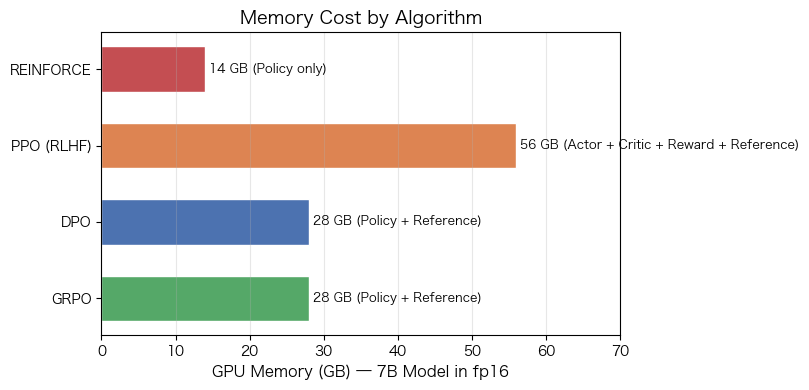

In [3]:
params_7b = 7e9
bytes_per_param = 2  # fp16
model_gb = params_7b * bytes_per_param / 1e9
print(f"One 7B model in fp16: {model_gb:.1f} GB\n")

configs = [
    ("REINFORCE", 1, "Policy only"),
    ("PPO (RLHF)", 4, "Actor + Critic + Reward + Reference"),
    ("DPO", 2, "Policy + Reference"),
    ("GRPO", 2, "Policy + Reference"),
]
fig, ax = plt.subplots(figsize=(8, 4))
names = [c[0] for c in configs]
mem = [c[1] * model_gb for c in configs]
colors = ['#C44E52', '#DD8452', '#4C72B0', '#55A868']
bars = ax.barh(names, mem, color=colors, edgecolor='white', height=0.6)
for bar, m, (_, n, desc) in zip(bars, mem, configs):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{m:.0f} GB ({desc})', va='center', fontsize=9)
ax.set_xlabel("GPU Memory (GB) — 7B Model in fp16", fontsize=11)
ax.set_title("Memory Cost by Algorithm", fontsize=13, fontweight='bold')
ax.set_xlim(0, 70)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

info_box(f"PPO needs ~{4*model_gb:.0f} GB just for model weights — before optimizer states "
         f"and activations! DPO/GRPO halve this to ~{2*model_gb:.0f} GB.",
         title="Memory Reality Check")

## 3 — LLM 强化学习的演进

LLM 强化学习的发展史就是一个渐进简化的故事。每一种新算法都解决了前一种方法的特定痛点：

| 年份 | 里程碑 | 解决了什么问题 |
|---|---|---|
| 2017 | **PPO**（Schulman et al.） | 通过裁剪实现稳定的策略优化 |
| 2022 | **大规模 RLHF**（InstructGPT / ChatGPT） | 证明 PPO + 人类反馈适用于聊天对齐 |
| 2023 | **DPO**（Rafailov et al.） | 完全移除了奖励模型 |
| 2024 | **SAPO、KTO、IPO** | 自对齐、更简单的损失函数、无需偏好对 |
| 2025 | **GRPO / DeepSeek-R1** | 移除了评论家，实现了涌现推理 |

趋势清晰可见：**更少的模型、更简单的损失函数、更自主的改进。**

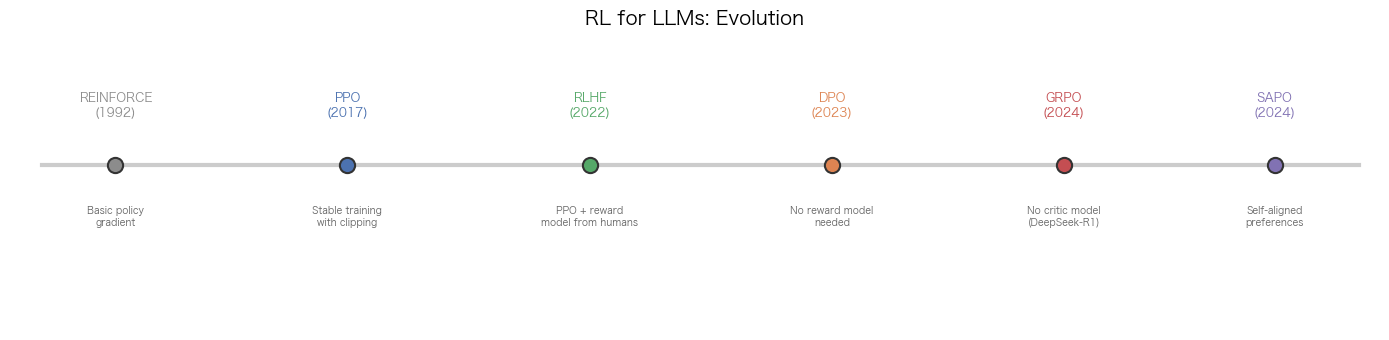

In [4]:
fig, ax = draw_method_timeline()
plt.show()

## 4 — SAPO：自对齐偏好优化（Self-Aligned Preference Optimization）

我们之前介绍的算法都需要某种形式的外部信号：奖励函数、人类偏好标注或验证器（Verifier）。**SAPO**（自对齐偏好优化，Self-Aligned Preference Optimization）将前沿推得更远：**如果模型能自我改进呢？**

核心思想：

1. 用当前策略对同一提示**生成**两个（或更多）回复。
2. 用质量信号**评分**这些回复——可以是长度、连贯性、自一致性（模型再次被问到时是否同意自己的答案？）或轻量级验证器。
3. **创建偏好对**：得分更高的回复成为"偏好"输出，得分更低的成为"拒绝"输出。
4. 用 **DPO 风格的损失函数**在这些自生成的偏好对上训练。
5. **重复**——改进后的模型在下一轮生成更好的回复。

这创建了一个**自我改进循环（Self-Improvement Loop）**：模型自举式地生成自己的训练数据。

In [5]:
info_box("SAPO is exciting because it removes the last human bottleneck — preference annotation. "
         "The model generates its own training signal and improves itself iteratively. "
         "This is a step toward truly autonomous alignment.",
         title="Why SAPO Matters")

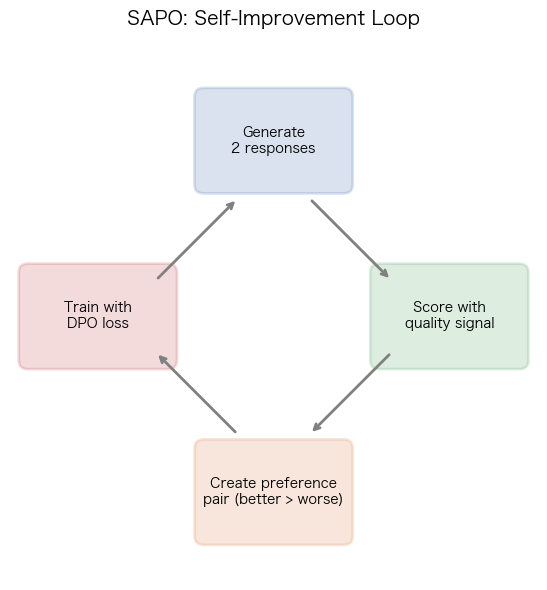

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.axis('off')

# Draw circular flow
angles = [90, 0, -90, -180]
labels = ['Generate\n2 responses', 'Score with\nquality signal',
          'Create preference\npair (better > worse)', 'Train with\nDPO loss']
colors_c = ['#4C72B0', '#55A868', '#DD8452', '#C44E52']

for i, (angle, label, color) in enumerate(zip(angles, labels, colors_c)):
    rad = np.radians(angle)
    x, y = np.cos(rad), np.sin(rad)
    circle = mpatches.FancyBboxPatch((x-0.4, y-0.25), 0.8, 0.5,
                                      boxstyle="round,pad=0.05",
                                      facecolor=color, alpha=0.2, edgecolor=color, lw=2)
    ax.add_patch(circle)
    ax.text(x, y, label, ha='center', va='center', fontsize=10, fontweight='bold')

# Draw arrows between nodes
for i in range(4):
    a1 = np.radians(angles[i])
    a2 = np.radians(angles[(i+1) % 4])
    # Arrow from node i to node i+1
    x1, y1 = 0.7*np.cos(a1 - 0.3), 0.7*np.sin(a1 - 0.3)
    x2, y2 = 0.7*np.cos(a2 + 0.3), 0.7*np.sin(a2 + 0.3)
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='gray', lw=2))

ax.set_title("SAPO: Self-Improvement Loop", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### 一句话概括演进

> REINFORCE（高噪声）→ **PPO**（稳定，4 个模型）→ **DPO**（更简单，2 个模型，离线）→ **GRPO**（更简单，2 个模型，在线）→ **SAPO**（自对齐）

每一步都移除了一个组件或一个依赖。这个领域正在向**更简单、更廉价、更自主**的算法收敛。

## 5 — 哪些 LLM 在使用什么方法？

这些算法不是学术上的好奇心——它们驱动着你每天使用的模型。

In [7]:
comparison_table(
    headers=["Model", "Method", "Key Innovation"],
    rows=[
        ["ChatGPT / GPT-4", "PPO (RLHF)", "Pioneered RLHF at scale"],
        ["Claude", "RLHF + Constitutional AI", "AI feedback for safety"],
        ["Llama-2-Chat", "PPO (RLHF)", "Rejection sampling + PPO"],
        ["Zephyr", "DPO", "Showed DPO can match RLHF"],
        ["DeepSeek-R1", "GRPO", "Group-relative advantage, emergent reasoning"],
        ["Qwen-2", "DPO + GRPO", "Hybrid approach"],
    ],
    title="RL Methods in Production LLMs"
)

Model,Method,Key Innovation
ChatGPT / GPT-4,PPO (RLHF),Pioneered RLHF at scale
Claude,RLHF + Constitutional AI,AI feedback for safety
Llama-2-Chat,PPO (RLHF),Rejection sampling + PPO
Zephyr,DPO,Showed DPO can match RLHF
DeepSeek-R1,GRPO,"Group-relative advantage, emergent reasoning"
Qwen-2,DPO + GRPO,Hybrid approach


---

## 第二部分 — 强化学习训练的分布式系统

在大规模训练 LLM 时，强化学习对齐引入了**超越标准预训练**的独特分布式系统挑战。预训练"只是"在文本数据上进行大规模的前向-反向循环。强化学习对齐增加了生成、多模型和在策略（On-Policy）约束。

让我们探讨三个主要挑战。

### 挑战 1：多模型编排（Multi-Model Orchestration）

预训练涉及**一个模型**。强化学习对齐涉及**两到四个**：

| 算法 | 模型数 | 说明 |
|---|---|---|
| PPO | 4 | 演员（Actor）、评论家（Critic）、奖励（Reward）、参考（Reference） |
| DPO | 2 | 策略（Policy）、参考（Reference） |
| GRPO | 2 | 策略（Policy）、参考（Reference） |

这些模型有**不同的计算模式**：
- 有些是**冻结的**（参考模型、奖励模型）——仅推理
- 有些在**训练**（演员、评论家）——前向 + 反向 + 优化器步骤
- 它们需要在步骤之间**通信**结果（奖励、对数概率、优势）

调度和内存管理变得至关重要。你不能简单地对整个系统进行"数据并行"——每个模型有不同的资源需求和生命周期。

### 挑战 2：生成瓶颈（Generation Bottleneck）

强化学习对齐要求模型**生成文本**（自回归解码，逐 token 生成）。这与标准训练步骤根本不同——而且慢得多。

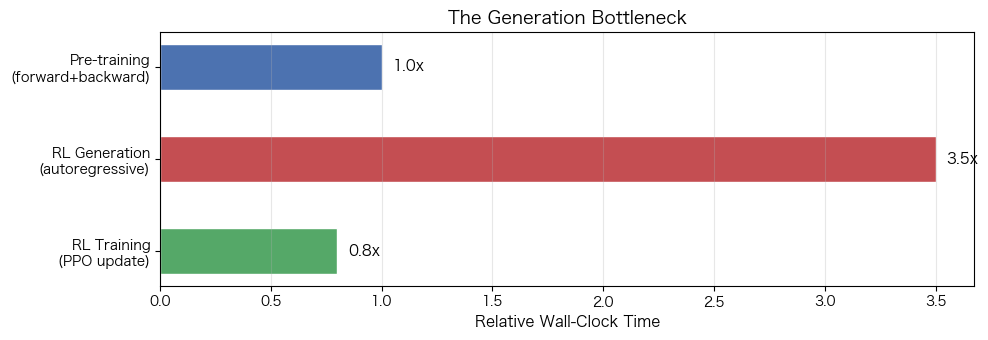

In [8]:
# Illustrate the bottleneck
fig, ax = plt.subplots(figsize=(10, 3.5))
tasks = ['Pre-training\n(forward+backward)', 'RL Generation\n(autoregressive)',
         'RL Training\n(PPO update)']
# Relative time estimates
times = [1.0, 3.5, 0.8]
colors_t = ['#4C72B0', '#C44E52', '#55A868']
bars = ax.barh(tasks, times, color=colors_t, edgecolor='white', height=0.5)
for bar, t in zip(bars, times):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{t:.1f}x', va='center', fontsize=11, fontweight='bold')
ax.set_xlabel("Relative Wall-Clock Time", fontsize=11)
ax.set_title("The Generation Bottleneck", fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

info_box("Autoregressive generation is 3-4x slower than a training step. "
         "Optimizing generation throughput (batching, speculative decoding, vLLM) "
         "is critical for RL training speed.",
         title="The Generation Bottleneck")

### 挑战 3：在策略数据新鲜度（On-Policy Data Freshness）

PPO 和 GRPO 是**在策略（On-Policy）**算法：它们的训练数据必须来自**当前**模型。你不能预先生成一个大数据集然后反复迭代（那是 DPO 的方法）。

这创建了一个**生成 → 训练 → 生成 → 训练**的循环：

1. 用当前策略**生成**一批回复
2. 对它们**评分**（奖励模型或验证器）
3. 在这些回复上**训练**策略
4. **丢弃**这些数据——它们现在已经离策略了
5. 从步骤 1 **重复**

问题是：**流水线气泡（Pipeline Bubbles）**。生成期间，训练 GPU 闲置。训练期间，生成 GPU 闲置。这浪费了昂贵的计算资源。

> **终极目标：** 重叠生成和训练，让所有 GPU 始终保持忙碌。

## 6 — GPU 放置策略（GPU Placement Strategies）

如何将 2 到 4 个大模型放到 GPU 上？两种主要方法：

**共置（Colocated）：** 所有模型共享相同的 GPU。实现简单但内存严重受限——你需要足够的内存同时容纳所有模型。

**分离（Separated）：** 每个模型有专用的 GPU 组。总可用内存更多，但编排复杂——模型必须跨组相互发送数据。

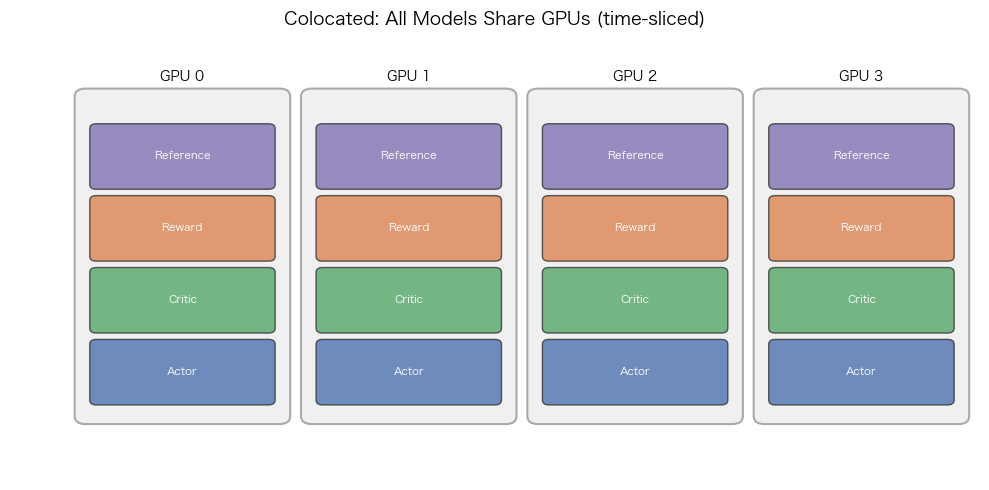

In [9]:
fig1, ax1 = draw_rl_gpu_placement(strategy="colocated")
plt.show()

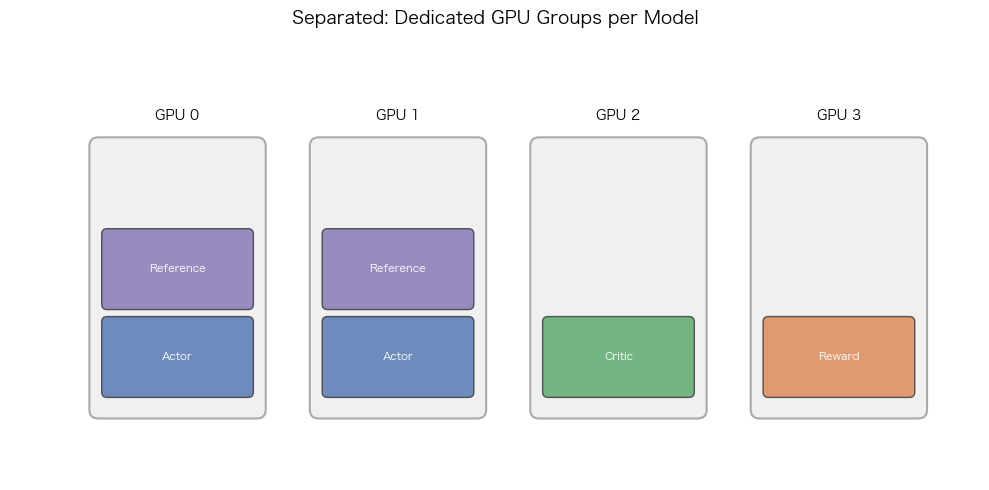

In [10]:
fig2, ax2 = draw_rl_gpu_placement(strategy="separated")
plt.show()

## 7 — 强化学习训练框架

已有多个框架涌现来应对这些分布式挑战。每个框架在简单性和性能之间做出了不同的权衡。

In [11]:
comparison_table(
    headers=["Framework", "Strategy", "Key Idea", "Best For"],
    rows=[
        ["DeepSpeed-Chat", "Colocated → Separated", "All models on same GPUs, then offload", "Getting started"],
        ["OpenRLHF", "Separated (Ray)", "Dedicated GPU groups, Ray orchestration", "Large-scale PPO"],
        ["veRL (Volcano Engine)", "Hybrid SPMD", "Flexible placement, overlaps gen + train", "Maximum throughput"],
        ["TRL", "Colocated (HF)", "HuggingFace ecosystem integration", "Prototyping"],
    ],
    title="RL Training Frameworks"
)

Framework,Strategy,Key Idea,Best For
DeepSpeed-Chat,Colocated → Separated,"All models on same GPUs, then offload",Getting started
OpenRLHF,Separated (Ray),"Dedicated GPU groups, Ray orchestration",Large-scale PPO
veRL (Volcano Engine),Hybrid SPMD,"Flexible placement, overlaps gen + train",Maximum throughput
TRL,Colocated (HF),HuggingFace ecosystem integration,Prototyping


In [12]:
code_reference(
    code="""\
# OpenRLHF: Actor-Critic separated across GPU groups
class PPOTrainer:
    def __init__(self, actor, critic, reward_model, ref_model):
        # Each model can be on different GPU groups
        self.actor = ActorModelRayActor(actor, gpu_group_0)
        self.critic = CriticModelRayActor(critic, gpu_group_1)
        self.reward = RewardModelRayActor(reward_model, gpu_group_2)
        self.ref = RefModelRayActor(ref_model, gpu_group_0)  # shares with actor

    def step(self, prompts):
        # 1. Generate with actor (SLOW — generation bottleneck)
        sequences = self.actor.generate(prompts)
        # 2. Score with reward model
        rewards = self.reward.score(sequences)
        # 3. Compute values with critic
        values = self.critic.evaluate(sequences)
        # 4. PPO update (FAST — standard training step)
        self.actor.ppo_step(sequences, rewards, values)""",
    source="OpenRLHF",
    filepath="openrlhf/trainer/ppo_trainer.py"
)

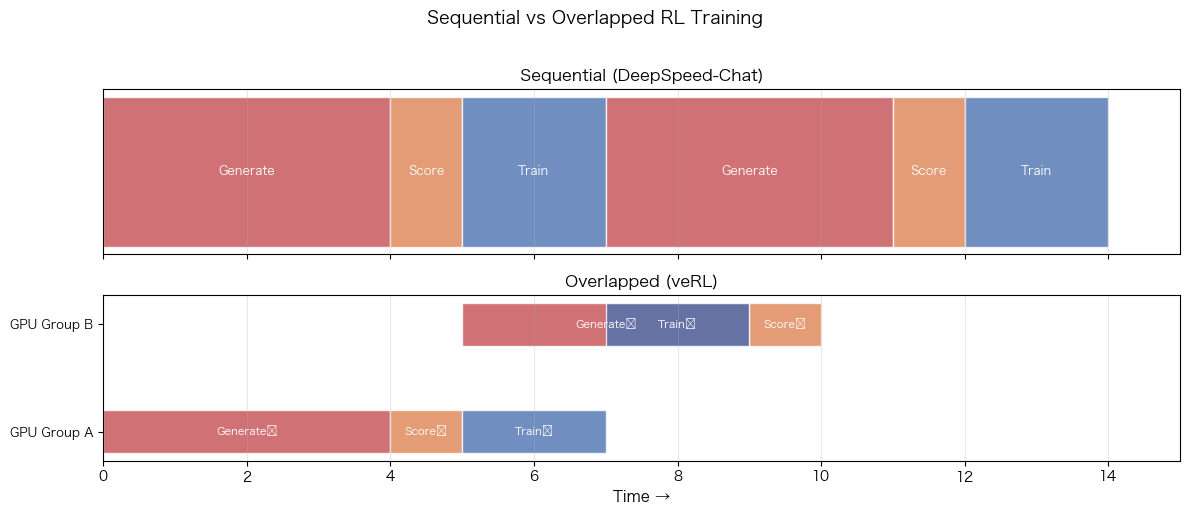

In [13]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

# Sequential timeline
tasks_seq = [
    ('Generate', 0, 4, '#C44E52'),
    ('Score', 4, 1, '#DD8452'),
    ('Train', 5, 2, '#4C72B0'),
    ('Generate', 7, 4, '#C44E52'),
    ('Score', 11, 1, '#DD8452'),
    ('Train', 12, 2, '#4C72B0'),
]
for name, start, dur, color in tasks_seq:
    ax1.barh(0, dur, left=start, height=0.5, color=color, edgecolor='white', alpha=0.8)
    ax1.text(start + dur/2, 0, name, ha='center', va='center', fontsize=9, fontweight='bold', color='white')
ax1.set_title("Sequential (DeepSpeed-Chat)", fontweight='bold')
ax1.set_yticks([])
ax1.set_xlim(0, 15)
ax1.grid(axis='x', alpha=0.3)

# Overlapped timeline
tasks_over = [
    ('Generate\u2081', 0, 4, '#C44E52', 0),
    ('Score\u2081', 4, 1, '#DD8452', 0),
    ('Train\u2081', 5, 2, '#4C72B0', 0),
    ('Generate\u2082', 5, 4, '#C44E52', 1),  # Overlap!
    ('Score\u2082', 9, 1, '#DD8452', 1),
    ('Train\u2082', 7, 2, '#4C72B0', 1),
]
for name, start, dur, color, row in tasks_over:
    ax2.barh(row, dur, left=start, height=0.4, color=color, edgecolor='white', alpha=0.8)
    ax2.text(start + dur/2, row, name, ha='center', va='center', fontsize=8, fontweight='bold', color='white')
ax2.set_title("Overlapped (veRL)", fontweight='bold')
ax2.set_yticks([0, 1])
ax2.set_yticklabels(["GPU Group A", "GPU Group B"], fontsize=9)
ax2.set_xlabel("Time \u2192", fontsize=11)
ax2.set_xlim(0, 15)
ax2.grid(axis='x', alpha=0.3)

plt.suptitle("Sequential vs Overlapped RL Training", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

info_box("By overlapping generation and training across GPU groups, veRL achieves "
         "~1.5x throughput over sequential approaches. The key: start generating "
         "the next batch while training on the current one.",
         title="Overlap = Throughput")

## 8 — 全局视角

让我们把所有内容串联起来。

**强化学习对齐是 LLM 训练的最后阶段**，在预训练和监督微调之后。它将一个有能力但不受控的模型转变为一个能遵循指令、避免伤害、善于推理的模型。

**存在多种算法**，每种在简单性、内存成本、探索能力和数据需求之间有不同的权衡。没有单一的"最佳"算法——选择取决于你的约束条件。

**这个领域发展迅速。** 每隔几个月就会出现新算法。趋势是向更简单的方法发展，需要更少的模型和更少的人类标注。

**工程挑战与算法进步同等重要。** 你可以拥有世界上最好的算法，但如果不能在数百块 GPU 上高效运行，它就不实用。多模型编排、生成瓶颈和在策略数据新鲜度是影响实际部署的真实约束。

## 总结 — 完整章节回顾

本章涵盖了 LLM 强化学习对齐的完整版图，从第一性原理到生产系统。

### 逐 Notebook 回顾

1. **基础（nb 00）：** 强化学习 = 生成 → 评分 → 学习 → 重复。REINFORCE 是最简单的算法——单一策略，高方差，但为所有后续方法奠定了基础。

2. **PPO（nb 01）：** 通过裁剪代理目标增加稳定性，通过 KL 惩罚保障安全性，通过多轮更新提高效率。需要 4 个模型在内存中。

3. **DPO（nb 02）：** 通过数学捷径（Bradley-Terry → 封闭形式最优策略）消除了奖励模型。只需 2 个模型，离线训练，极其简单的损失函数。

4. **GRPO（nb 03）：** 通过群组相对优势估计消除了评论家。只需 2 个模型，在线训练，无价值函数。驱动了 DeepSeek-R1 的涌现推理。

5. **前沿（nb 04，本 notebook）：** SAPO 用于自对齐——模型生成自己的偏好数据。分布式挑战：多模型编排、生成瓶颈、在策略数据新鲜度。框架版图：DeepSpeed-Chat、OpenRLHF、veRL、TRL。

> REINFORCE（高噪声）→ **PPO**（稳定，4 个模型）→ **DPO**（更简单，2 个模型，离线）→ **GRPO**（更简单，2 个模型，在线）→ **SAPO**（自对齐）

## 延伸阅读

### 论文

- **PPO** — Schulman et al., 2017. [arXiv 1707.06347](https://arxiv.org/abs/1707.06347)
- **RLHF (InstructGPT)** — Ouyang et al., 2022. [arXiv 2203.02155](https://arxiv.org/abs/2203.02155)
- **DPO** — Rafailov et al., 2023. [arXiv 2305.18290](https://arxiv.org/abs/2305.18290)
- **GRPO / DeepSeek-R1** — 2025. [arXiv 2501.12948](https://arxiv.org/abs/2501.12948)
- **SAPO** — 2024. [arXiv 2405.07863](https://arxiv.org/abs/2405.07863)

### 框架

- [DeepSpeed-Chat](https://github.com/microsoft/DeepSpeedExamples/tree/master/applications/DeepSpeed-Chat) — 微软的端到端 RLHF 管线
- [OpenRLHF](https://github.com/OpenRLHF/OpenRLHF) — 基于 Ray 的可扩展 RLHF，支持模型分离
- [veRL](https://github.com/volcengine/verl) — 火山引擎的混合 SPMD 强化学习训练框架
- [TRL](https://github.com/huggingface/trl) — HuggingFace 的 Transformer 强化学习库